# Analysis of Outcomes

In [96]:
import pandas as pd
df = pd.read_csv("output.csv")

## Compare Ground Truth

In [97]:
from pathlib import Path
import json

def compare_llm_to_ground_truth(llm_output_path: Path, ground_truth_path: Path):
    """
    Compare LLM output to ground truth data.
    Returns a DataFrame with the comparison results.
    """
    comparison_results = []
    print(f"Comparing LLM output in {llm_output_path} to ground truth in {ground_truth_path}")
    for llm_file in llm_output_path.glob("*.json"):
        paper_id = llm_file.stem
        ground_truth_file = ground_truth_path / f"{paper_id}.json"

        if not ground_truth_file.exists():
            print(f"Ground truth file not found for {paper_id}")
            continue
        print(f"Comparing {paper_id}...")
        llm_data = json.load(open(llm_file))
        ground_truth_data = json.load(open(ground_truth_file))

        for key in llm_data.keys(): # looping through the top level keys in the LLM output JSON (Meta, Hypothesis, Experiments, Analyses, Future Work, Interpretation)
            if key in ["Meta"]: continue  # Skip Meta section
            if key not in ground_truth_data: # Sanity check, should not happen if ground truth is complete
                print(f"Key '{key}' not found in ground truth for {paper_id}")
                raise KeyError(f"Key '{key}' not found in ground truth for {paper_id}")
            
            llm_section = llm_data.get(key, {}) # underlying dictionary for the current section (e.g., Hypothesis, Experiments, Analyses, Future Work, Interpretation)
            gt_section = ground_truth_data.get(key, {})
            
            if key != "Future Work":
                for item_id, gt_item in gt_section.items():
                    llm_item = llm_section.get(item_id, {})
                    for field in gt_item.keys():
                        if (field not in gt_item) and (field not in llm_item):
                            print(f"Field '{field}' not found in both LLM and ground truth for item '{item_id}' in paper '{paper_id}'")
                            continue
                        comparison_results.append({
                            "Paper": paper_id,
                            "Section": key,
                            "Item": item_id,
                            "Field": f"{key} {field.capitalize()}",
                            "LLM": llm_item.get(field, "MISSING"),
                            "Ground Truth": gt_item.get(field, "MISSING"),
                            "Match": llm_item.get(field, "MISSING") == gt_item.get(field, "MISSING")
                        })
                llm_keys = set(llm_section.keys())
                gt_keys = set(gt_section.keys())
                extra_llm_keys = llm_keys - gt_keys
                if bool(extra_llm_keys):
                    for extra_key in extra_llm_keys:
                        llm_item = llm_section.get(extra_key, {})
                        for field in llm_item.keys():
                            comparison_results.append({
                                "Paper": paper_id,
                                "Section": key,
                                "Item": extra_key,
                                "Field": f"{key} {field.capitalize()}",
                                "LLM": llm_item.get(field, "MISSING"),
                                "Ground Truth": "EXTRA KEY IN LLM OUTPUT",
                                "Match": False
                            })
            else: 
                for item_top_id, gt_top_item in gt_section.items():
                    for item_id, gt_item in gt_top_item.items():
                        llm_item = llm_section.get(item_top_id, {}).get(item_id, {})
                        for field in gt_item.keys():
                            if (field not in gt_item) and (field not in llm_item):
                                print(f"Field '{field}' not found in both LLM and ground truth for item '{item_id}' in paper '{paper_id}'")
                                continue
                            comparison_results.append({
                                "Paper": paper_id,
                                "Section": key,
                                "Item": item_id,
                                "Field": f"{key} {field.capitalize()}",
                                "LLM": llm_item.get(field, "MISSING"),
                                "Ground Truth": gt_item.get(field, "MISSING"),
                                "Match": llm_item.get(field, "MISSING") == gt_item.get(field, "MISSING")
                            })
                    llm_keys = set(llm_section.keys())
                    gt_keys = set(gt_section.keys())
                    extra_llm_keys = llm_keys - gt_keys
                    if bool(extra_llm_keys):
                        for extra_key in extra_llm_keys:
                            llm_item = llm_section.get(extra_key, {})
                            for field in llm_item.keys():
                                comparison_results.append({
                                    "Paper": paper_id,
                                    "Section": key,
                                    "Item": extra_key,
                                    "Field": f"{key} {field.capitalize()}",
                                    "LLM": llm_item.get(field, "MISSING"),
                                    "Ground Truth": "EXTRA KEY IN LLM OUTPUT",
                                    "Match": False
                                })

                    
        
    return pd.DataFrame(comparison_results)

In [98]:
llm_output_path = Path("./llm_output")
ground_truth_path = Path("./ground_truth")

comparison_df = compare_llm_to_ground_truth(llm_output_path, ground_truth_path)

Comparing LLM output in llm_output to ground truth in ground_truth
Comparing Edge-Based Graph Component Pooling...
Comparing Data Efficient Pre-training for Language Models An Empirical Study of Compute Efficiency and Linguistic Competence...
Comparing Automatic Adjusting Global Similarity Measures in Learning CBR Systems...
Comparing Rethinking Evaluation Paradigms in IBP-based Certified Training...
Comparing Towards Consistent and Efficient Decision-based Attacks...
Ground truth file not found for Exploring the Integration of Spatial Information into a Spectral Clustering Approach to Unsupervised Band Selection
Comparing An Evaluation of Neural Network Architectures for Predicting Hydro Unit Commitment Decisions...
Comparing Applying and benchmarking a stochastic programming-based bidding strategy for day-ahead hydropower scheduling...
Comparing Instance selection for configuration performance comparison...
Comparing Leveraging AutoML for Sustainable Deep Learning: A Multi- Objective

In [99]:
comparison_df.head()

,Paper,Section,Item,Field,LLM,Ground Truth,Match
0,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Explicit,False,False,True
1,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Value,How can a graph pooling operator be designed t...,How can a graph pooling operator be designed t...,True
2,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Reason,Abstract: 'We propose a pooling operator that ...,Abstract: 'We propose a pooling operator that ...,True
3,Edge-Based Graph Component Pooling,Research Questions,research_question_2,Research Questions Explicit,False,False,True
4,Edge-Based Graph Component Pooling,Research Questions,research_question_2,Research Questions Value,Does the proposed edge-based graph component p...,Does the proposed edge-based graph component p...,True


In [100]:
tot_missing = (comparison_df["LLM"] == "MISSING").groupby(comparison_df["Section"]).sum()
tot_extra = (comparison_df["Ground Truth"] == "EXTRA KEY IN LLM OUTPUT").groupby(comparison_df["Section"]).sum()

print("Total Missing Fields by Section:")
print(tot_missing)
print("\nTotal Extra Fields by Section:")
print(tot_extra)

Total Missing Fields by Section:
Section
Analyses              32
Conclusions           24
Experiments            0
Future Work           28
Hypotheses             0
Interpretations       15
Research Questions     3
Name: LLM, dtype: int64

Total Extra Fields by Section:
Section
Analyses              0
Conclusions           0
Experiments           0
Future Work           0
Hypotheses            8
Interpretations       3
Research Questions    6
Name: Ground Truth, dtype: int64


In [101]:
# Calculate match counts per Section and Field
matches_df = comparison_df[comparison_df['Match'] == True]
match_counts_by_section_field = matches_df.groupby(['Section', 'Field']).size().reset_index(name='Match_Count')

# Calculate total counts per Section and Field
total_counts_by_section_field = comparison_df.groupby(['Section', 'Field']).size().reset_index(name='Total_Count')

# Merge total and match counts
analysis_df = pd.merge(total_counts_by_section_field, match_counts_by_section_field, on=['Section', 'Field'], how='left')
analysis_df['Match_Count'] = analysis_df['Match_Count'].fillna(0).astype(int)

# Calculate match percentage
analysis_df['Accuracy_Percentage'] = (analysis_df['Match_Count'] / analysis_df['Total_Count']) * 100

# Print the results, section by section
for section, group in analysis_df.groupby('Section'):
    print(f"--- Section: {section} ---")
    # Sort by percentage ascending to show lowest accuracy first
    sorted_group = group.sort_values('Accuracy_Percentage', ascending=True)
    for _, row in sorted_group.iterrows():
        print(f"  Field: {row['Field']:<35} | Accuracy: {row['Match_Count']}/{row['Total_Count']} ({row['Accuracy_Percentage']:.2f}%)")
    print('\n')

--- Section: Analyses ---
  Field: Analyses Results                    | Accuracy: 62/88 (70.45%)
  Field: Analyses Reason                     | Accuracy: 75/88 (85.23%)
  Field: Analyses Statistics                 | Accuracy: 76/86 (88.37%)
  Field: Analyses Metrics                    | Accuracy: 80/88 (90.91%)
  Field: Analyses Test                       | Accuracy: 80/86 (93.02%)
  Field: Analyses Experiments                | Accuracy: 82/88 (93.18%)


--- Section: Conclusions ---
  Field: Conclusions Value                   | Accuracy: 40/55 (72.73%)
  Field: Conclusions Interpretations         | Accuracy: 45/55 (81.82%)
  Field: Conclusions Support                 | Accuracy: 47/55 (85.45%)
  Field: Conclusions Hypotheses              | Accuracy: 48/55 (87.27%)
  Field: Conclusions Research_questions      | Accuracy: 48/55 (87.27%)
  Field: Conclusions Reason                  | Accuracy: 51/55 (92.73%)


--- Section: Experiments ---
  Field: Experiments Strategy                | A

In [102]:
comparison_df[comparison_df["LLM"] == "MISSING"]

,Paper,Section,Item,Field,LLM,Ground Truth,Match
146,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Conclusions,MISSING,"[conclusion_1, conclusion_2]",False
147,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Value,MISSING,How do other datasets from other specific subd...,False
148,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Note,MISSING,Section 5 (Limitations and Future Work),False
149,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_4,Future Work Reason,MISSING,Suggested RQ1 has an overarching question to i...,False
150,Data Efficient Pre-training for Language Model...,Future Work,suggested_research_question_5,Future Work Conclusions,MISSING,[conclusion_2],False
...,...,...,...,...,...,...,...
2232,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Research_questions,MISSING,[research_question_1],False
2233,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Hypotheses,MISSING,[hypothesis_1],False
2234,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Support,MISSING,[True],False
2235,AutoMergeNet- AutoML-Based M-Source Satellite ...,Conclusions,conclusion_3,Conclusions Value,MISSING,"On both datasets, the CNN was chosen most freq...",False


In [103]:
comparison_df[comparison_df["Ground Truth"] == "EXTRA KEY IN LLM OUTPUT"]

,Paper,Section,Item,Field,LLM,Ground Truth,Match
451,Applying and benchmarking a stochastic program...,Interpretations,interpretation_2,Interpretations Analyses,[analysis_1],EXTRA KEY IN LLM OUTPUT,False
452,Applying and benchmarking a stochastic program...,Interpretations,interpretation_2,Interpretations Value,Significant differences in reservoir value (an...,EXTRA KEY IN LLM OUTPUT,False
453,Applying and benchmarking a stochastic program...,Interpretations,interpretation_2,Interpretations Reason,"Derived from Section 5.4, explaining why the s...",EXTRA KEY IN LLM OUTPUT,False
853,Weighted Initialisation of Evolutionary Instru...,Research Questions,research_question_1,Research Questions Explicit,False,EXTRA KEY IN LLM OUTPUT,False
854,Weighted Initialisation of Evolutionary Instru...,Research Questions,research_question_1,Research Questions Value,How can an evolutionary algorithm for polyphon...,EXTRA KEY IN LLM OUTPUT,False
855,Weighted Initialisation of Evolutionary Instru...,Research Questions,research_question_1,Research Questions Reason,"In the Abstract and Introduction (Page 1-2), t...",EXTRA KEY IN LLM OUTPUT,False
1254,Hyperparameters in Reinforcement Learning and ...,Research Questions,research_question_6,Research Questions Explicit,False,EXTRA KEY IN LLM OUTPUT,False
1255,Hyperparameters in Reinforcement Learning and ...,Research Questions,research_question_6,Research Questions Value,What are the tradeoffs for hyperparameter opti...,EXTRA KEY IN LLM OUTPUT,False
1256,Hyperparameters in Reinforcement Learning and ...,Research Questions,research_question_6,Research Questions Reason,Implied from Section 5 heading and introductio...,EXTRA KEY IN LLM OUTPUT,False
1674,Time Series Representations Classroom (TSRC) A...,Hypotheses,hypothesis_2,Hypotheses Explicit,False,EXTRA KEY IN LLM OUTPUT,False


In [104]:
# Check how many keys were merged out of existence
comparison_df[comparison_df["Ground Truth"] == "EXTRA KEY IN LLM OUTPUT"][["Paper", "Item"]].drop_duplicates()

,Paper,Item
451,Applying and benchmarking a stochastic program...,interpretation_2
853,Weighted Initialisation of Evolutionary Instru...,research_question_1
1254,Hyperparameters in Reinforcement Learning and ...,research_question_6
1674,Time Series Representations Classroom (TSRC) A...,hypothesis_2
1678,Time Series Representations Classroom (TSRC) A...,hypothesis_3


In [105]:
comparison_df

,Paper,Section,Item,Field,LLM,Ground Truth,Match
0,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Explicit,False,False,True
1,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Value,How can a graph pooling operator be designed t...,How can a graph pooling operator be designed t...,True
2,Edge-Based Graph Component Pooling,Research Questions,research_question_1,Research Questions Reason,Abstract: 'We propose a pooling operator that ...,Abstract: 'We propose a pooling operator that ...,True
3,Edge-Based Graph Component Pooling,Research Questions,research_question_2,Research Questions Explicit,False,False,True
4,Edge-Based Graph Component Pooling,Research Questions,research_question_2,Research Questions Value,Does the proposed edge-based graph component p...,Does the proposed edge-based graph component p...,True
...,...,...,...,...,...,...,...
2317,Towards General Negotiation Strategies with En...,Future Work,suggested_research_question_2,Future Work Reason,The authors suggest this to address the limita...,The authors suggest this to address the limita...,True
2318,Towards General Negotiation Strategies with En...,Future Work,suggested_research_question_3,Future Work Conclusions,[conclusion_1],[conclusion_1],True
2319,Towards General Negotiation Strategies with En...,Future Work,suggested_research_question_3,Future Work Value,How can the method be improved to handle conti...,How can the method be improved to handle conti...,True
2320,Towards General Negotiation Strategies with En...,Future Work,suggested_research_question_3,Future Work Note,Section 5 (Conclusion),Section 5 (Conclusion),True


In [106]:
# Check how often strings were changed
string_changes = 0
total_options = 0
for row in comparison_df.iterrows():
    if "Value" not in row[1]["Field"]:
        continue
    total_options += 1
    if row[1]["LLM"] != row[1]["Ground Truth"]:
        string_changes += 1
print(f"The authors adapted {string_changes} out of {total_options} statements.  ({string_changes/total_options:.2%})")

The authors adapted 77 out of 374 statements.  (20.59%)


In [107]:
result_match_item = (
    comparison_df[(comparison_df['LLM']!='MISSING') & (comparison_df['Ground Truth']!='EXTRA KEY IN LLM OUPUT')].groupby(['Paper', 'Section', 'Item'], as_index=False)
      .agg(RelMatch=('Match', 'mean'))
)

In [108]:
unique_relmatch_counts = (
    result_match_item
    .groupby(['Section', 'RelMatch'])
    .size()
    .reset_index(name='Count')
    .sort_values(['Section', 'Count'], ascending=[True, False])
)

unique_relmatch_counts

,Section,RelMatch,Count
3,Analyses,1.000000,53
2,Analyses,0.833333,22
1,Analyses,0.666667,6
0,Analyses,0.500000,1
7,Conclusions,1.000000,31
6,Conclusions,0.833333,16
5,Conclusions,0.666667,3
4,Conclusions,0.166667,1
11,Experiments,1.000000,43
10,Experiments,0.800000,22


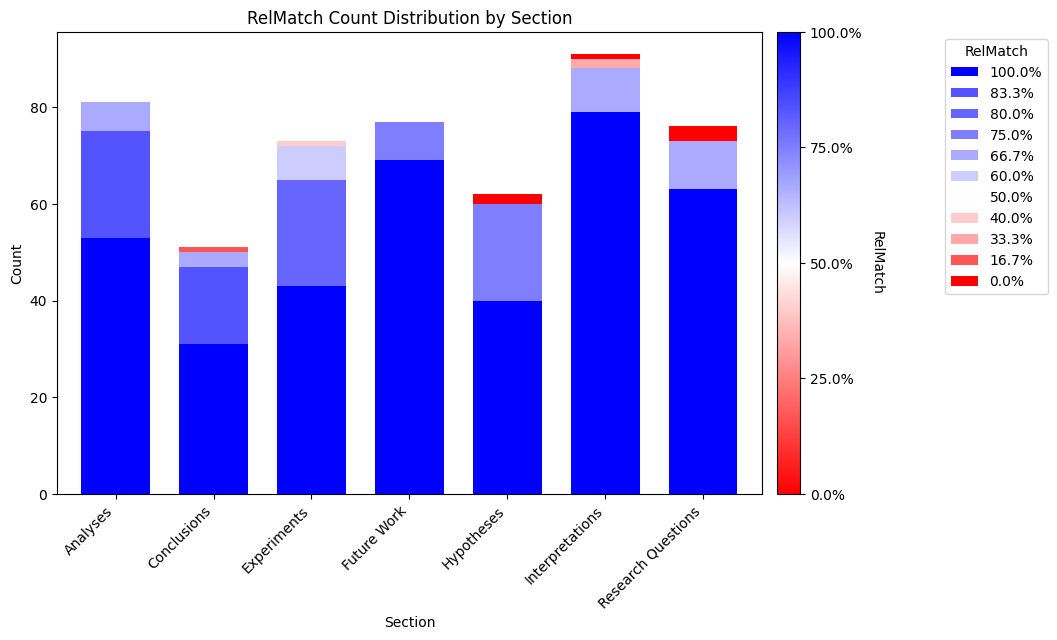

In [109]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter

# Prepare data
plot_df = (
    unique_relmatch_counts
    .pivot(index="Section", columns="RelMatch", values="Count")
    .sort_index(axis=1, ascending=False)
)

relmatch_values = plot_df.columns.astype(float)

# Color mapping: RelMatch 0.0 = red, 1.0 = blue
cmap = plt.colormaps["bwr_r"]
norm = Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in relmatch_values]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    width=0.7,
    edgecolor="none"
)

# Labels
ax.set(
    xlabel="Section",
    ylabel="Count",
    title="RelMatch Count Distribution by Section"
)

# Rotate x-axis labels
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Move legend further right
ax.legend(
    title="RelMatch",
    labels=[f"{v:.1%}" for v in relmatch_values],
    bbox_to_anchor=(1.25, 1),
    loc="upper left"
)

# Continuous colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.04,
    pad=0.02
)

cbar.set_label("RelMatch", rotation=270, labelpad=15)
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1, decimals=1)
)

# Reserve space on the right for both colorbar and legend
fig.subplots_adjust(right=0.75)

plt.show()

In [110]:
unique_relmatch_percentage = (
    result_match_item
    .groupby(['Section', 'RelMatch'])
    .size()
    .reset_index(name='Count')
    .assign(
        Percentage=lambda df: (
            df['Count']
            / df.groupby('Section')['Count'].transform('sum')
        )
    )
    .sort_values(['Section', 'Percentage'], ascending=[True, False])
)

unique_relmatch_percentage['Percentage'] *= 100

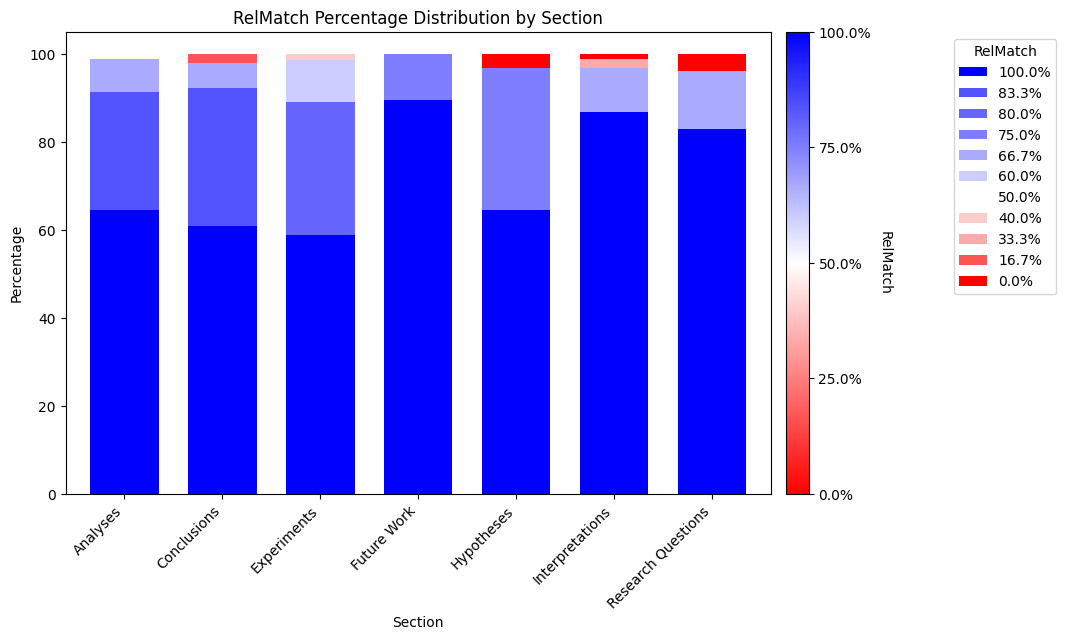

In [111]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter

# Prepare data
plot_df = (
    unique_relmatch_percentage
    .pivot(index="Section", columns="RelMatch", values="Percentage")
    .sort_index(axis=1, ascending=False)
)

relmatch_values = plot_df.columns.astype(float)

# Color mapping: RelMatch 0.0 = red, 1.0 = blue
cmap = plt.colormaps["bwr_r"]
norm = Normalize(vmin=0, vmax=1)
colors = [cmap(norm(v)) for v in relmatch_values]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    width=0.7,
    edgecolor="none"
)

# Labels
ax.set(
    xlabel="Section",
    ylabel="Percentage",
    title="RelMatch Percentage Distribution by Section"
)

# Rotate x-axis labels
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

# Move legend further right
ax.legend(
    title="RelMatch",
    labels=[f"{v:.1%}" for v in relmatch_values],
    bbox_to_anchor=(1.25, 1),
    loc="upper left"
)

# Continuous colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.04,
    pad=0.02
)

cbar.set_label("RelMatch", rotation=270, labelpad=15)
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1, decimals=1)
)

# Reserve space on the right for both colorbar and legend
fig.subplots_adjust(right=0.75)

plt.show()

In [112]:
cdfs = comparison_df.groupby('Section')
for name, cdf in cdfs:
    print(f"Section: {name}")
    for s in cdf['Field'].sort_values().unique():
        print(f"  Field: {s} - Type: {type(cdf[(cdf['Field'] == s) & (cdf['Ground Truth'] != 'EXTRA KEY IN LLM OUTPUT') & (cdf['LLM'] != 'MISSING')]['Ground Truth'].iloc[0])}")
    print('\n')

Section: Analyses
  Field: Analyses Experiments - Type: <class 'list'>
  Field: Analyses Metrics - Type: <class 'list'>
  Field: Analyses Reason - Type: <class 'str'>
  Field: Analyses Results - Type: <class 'dict'>
  Field: Analyses Statistics - Type: <class 'list'>
  Field: Analyses Test - Type: <class 'str'>


Section: Conclusions
  Field: Conclusions Hypotheses - Type: <class 'list'>
  Field: Conclusions Interpretations - Type: <class 'list'>
  Field: Conclusions Reason - Type: <class 'str'>
  Field: Conclusions Research_questions - Type: <class 'list'>
  Field: Conclusions Support - Type: <class 'list'>
  Field: Conclusions Value - Type: <class 'str'>


Section: Experiments
  Field: Experiments Data - Type: <class 'list'>
  Field: Experiments Experiment_description - Type: <class 'str'>
  Field: Experiments Hypotheses - Type: <class 'list'>
  Field: Experiments Research_questions - Type: <class 'list'>
  Field: Experiments Strategy - Type: <class 'str'>


Section: Future Work
  Fi